In [1]:
# taken from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Dataset, DataLoader
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.transforms.v2 as v2transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from PIL import Image
import skimage
from skimage import io, transform

In [2]:
batch_size = 118
image_size = 324
model_image_size = 64
workers = 2
rootdir = "/Users/ishwar/Downloads"
output_dir = "model_output_122525_64x64_t24"
if not os.path.isdir(output_dir):
    os.mkdir(output_dir)
NUM_LANDMARKS = 5

In [3]:
class SameSizeConv(nn.Module):
    def __init__(self, inchannels, outchannels, p_dropout, num_layers=2):
        super(SameSizeConv, self).__init__()
        self.p_dropout = p_dropout
        
        self.kernelSize = 3
        convs = []

        for _ in range(num_layers):
            convs.append(nn.Conv2d(inchannels, inchannels, self.kernelSize, stride=1, \
                    padding=(self.kernelSize-1)//2, bias=False) )
            convs.append(nn.BatchNorm2d(inchannels))
            convs.append(nn.LeakyReLU())
            convs.append(nn.Dropout(p=self.p_dropout))
            convs.append(nn.Conv2d(inchannels, inchannels, self.kernelSize+2, stride=1, \
                    dilation=2, padding=(self.kernelSize+2-1), bias=False) )
            convs.append(nn.BatchNorm2d(inchannels))
            convs.append(nn.LeakyReLU())
            convs.append(nn.Dropout(p=self.p_dropout))

        convs.append(nn.Conv2d(inchannels, inchannels, 1, stride=1, \
                            padding=0, bias=False) )
        convs.append(nn.BatchNorm2d(inchannels))
        convs.append(nn.LeakyReLU())
        convs.append(nn.Dropout(p=self.p_dropout))
        convs.append(nn.Conv2d(inchannels, outchannels, 1, stride=1, \
                            padding=0, bias=False) )
        convs.append(nn.BatchNorm2d(outchannels))
        convs.append(nn.LeakyReLU())
        convs.append(nn.Dropout(p=self.p_dropout))

        self.conv_layers = nn.Sequential(*convs)
    
    def forward(self, x):
        return self.conv_layers(x)

In [4]:
class Up(nn.Module):
    def __init__(self, in_channels, out_channels, up):
        super(Up, self).__init__()

        if up == None:
            self.up = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False)
        else:
            self.up = up
        self.kernelSize = 5
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU()
        self.conv_layers = SameSizeConv(out_channels*2, out_channels, 0)

    def forward(self, x1, x2):
        x = self.up(x1)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_layers(x)
        return x

In [5]:
class Up2(nn.Module):
    def __init__(self, in_channels, out_channels, up, num_layers=2):
        super(Up2, self).__init__()

        if up == None:
            self.up = nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False)
        else:
            self.up = up
        self.kernelSize = 5
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU()
        self.conv_layers = SameSizeConv(out_channels, out_channels, 0)

    def forward(self, x):
        x = self.up(x)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = self.conv_layers(x)
        return x

In [6]:
class Down(nn.Module):
    def __init__(self, in_channels, out_channels, down):
        super(Down, self).__init__()

        self.kernelSize = 5
        if down == None:
            self.down = nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)
        else:
            self.down = down
        self.batch_norm = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU()
        self.conv_layers = SameSizeConv(out_channels, out_channels, 0)

    def forward(self, x):
        x = self.down(x)
        x = self.batch_norm(x)
        x = self.activation(x)
        x = self.conv_layers(x)
        return x

In [7]:
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels, num_skip=6):
        super(UNet, self).__init__()
        
        self.modules = []
        self.kernelSize = 5 # must be odd
        self.p_dropout = 0
        self.num_skip = num_skip

        channels = (3, 8)
        self.init_conv = SameSizeConv(channels[0], channels[1], self.p_dropout)
        self.convs0 = SameSizeConv(channels[1], NUM_LANDMARKS + channels[1], self.p_dropout)
        self.convs0a = SameSizeConv(NUM_LANDMARKS + channels[1], 16, self.p_dropout)
        
        # downsizing
        channels = (8, 16)
        self.downsize1 = Down(channels[0], channels[1], None)
        self.ups1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.convs1 = SameSizeConv(channels[1], NUM_LANDMARKS + channels[1], self.p_dropout)
        self.convs1a = SameSizeConv(NUM_LANDMARKS + channels[1], channels[1], self.p_dropout)

        channels = (16, 32)
        self.downsize2 = Down(channels[0], channels[1], None)
        self.ups2 = nn.Upsample(scale_factor=4, mode='nearest')
        self.convs2 = SameSizeConv(channels[1], NUM_LANDMARKS + channels[1], self.p_dropout)
        self.convs2a = SameSizeConv(NUM_LANDMARKS + channels[1], channels[1], self.p_dropout)

        channels = (32, 64)
        self.downsize3 = Down(channels[0], channels[1], None)
        self.ups3 = nn.Upsample(scale_factor=8, mode='nearest')
        self.convs3 = SameSizeConv(channels[1], NUM_LANDMARKS + channels[1], self.p_dropout)
        self.convs3a = SameSizeConv(NUM_LANDMARKS + channels[1], channels[1], self.p_dropout)

        channels = (64, 128)
        self.downsize4 = Down(channels[0], channels[1], None)

        self.lowest_convs = SameSizeConv(channels[1], channels[1], self.p_dropout)

        num_skip_temp = self.num_skip

        channels = (128, 64)
        self.upsize4 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        num_skip_temp -= 1

        channels = (64, 32)
        self.upsize3 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        num_skip_temp -= 1

        channels = (32, 16)
        self.upsize2 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        num_skip_temp -= 1

        channels = (16, 16)
        self.upsize1 =  Up(channels[0], channels[1], None) if (num_skip_temp > 0) else Up2(channels[0], channels[1], None)
        num_skip_temp -= 1

        self.final_conv = SameSizeConv(channels[1], out_channels, self.p_dropout)


    def forward(self, input):
        x0 = self.init_conv(input)

        x1 = self.downsize1(x0)
        x1 = F.dropout(x1, p=self.p_dropout)

        x2 = self.downsize2(x1)
        x2 = F.dropout(x2, p=self.p_dropout)

        x3 = self.downsize3(x2)
        x3 = F.dropout(x3, p=self.p_dropout)

        x4 = self.downsize4(x3)
        x4 = F.dropout(x4, p=self.p_dropout)

        f5 = self.lowest_convs(x4)

        y3 = self.convs3(x3)
        y2 = self.convs2(x2)
        y1 = self.convs1(x1)
        y0 = self.convs0(x0)

        inter3 = self.ups3(y3[:, :NUM_LANDMARKS, :, :])
        inter2 = self.ups2(y2[:, :NUM_LANDMARKS, :, :])
        inter1 = self.ups1(y1[:, :NUM_LANDMARKS, :, :])
        inter0 = y0[:, :NUM_LANDMARKS, :, :]

        num_skip_temp = self.num_skip

        x = self.upsize4(f5, self.convs3a(y3)) if (num_skip_temp > 0) else self.upsize4(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.upsize3(x, self.convs2a(y2)) if (num_skip_temp > 0) else self.upsize3(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.upsize2(x, self.convs1a(y1)) if (num_skip_temp > 0) else self.upsize2(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.upsize1(x, self.convs0a(y0)) if (num_skip_temp > 0) else self.upsize1(x)
        x = F.dropout(x, p=self.p_dropout)
        num_skip_temp -= 1

        x = self.final_conv(x)

        return x, inter0, inter1, inter2, inter3

In [8]:
class StackedHourglass(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(StackedHourglass, self).__init__()
        self.unet1 = UNet(in_channels, out_channels)
        #self.unet2 = UNet(16, out_channels, num_skip=1)
        #self.unet3 = UNet(8, 8)
        #self.unet4 = UNet(8, out_channels)
    def forward(self, input):
        unet1_ans = self.unet1(input)
        x = unet1_ans[0]
        b = x.shape[0]
        c = x.shape[1]
        ret = [ F.softmax(heatmap.view(b, c, model_image_size*model_image_size), dim=2).view((b,c,model_image_size,model_image_size)) * (model_image_size**2) / 20
            for heatmap in unet1_ans ]
        #x = self.unet2(x)
        #x = self.unet3(x)
        #x = self.unet4(x)
        #x = F.sigmoid(x)
        return ret

In [9]:
# Dont USE
weight_spread = 0.05
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        #nn.init.normal_(m.weight.data, 0.0, 1/16) # not tried yet
        nn.init.normal_(m.weight.data, 0.0, weight_spread)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, weight_spread)
        nn.init.normal_(m.bias.data, 0.0, weight_spread)
    m = m.to(torch.float32)

clip_value =  5
class WeightConstraint(object):
    def __init__(self):
        pass
    def __call__(self, module):
        # filter the variables to get the ones you want
        if hasattr(module, 'weight'):
            w = module.weight.data
            w = w.clamp(-clip_value, clip_value)
            module.weight.data = w

In [10]:
# Set random seed for reproducibility
manualSeed = 499
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)

torch.use_deterministic_algorithms(True) # Needed for reproducible results

Random Seed:  499


In [11]:
MIN_SIGMA = 1
def gen_coordinates(coord_array):
    # make 7 coordinates from 5 coordinates
    coord_array_new = torch.zeros((NUM_LANDMARKS, 2))
    coord_array_new[0] = coord_array[0]
    coord_array_new[1] = coord_array[1]
    coord_array_new[2] = (1/2)*((3/5)*coord_array[3] + (2/5)*coord_array[0]) + (1/2)*coord_array[1] # on left wing
    coord_array_new[3] = coord_array[2]
    coord_array_new[4] = (1/2)*((3/5)*coord_array[3] + (2/5)*coord_array[0]) + (1/2)*coord_array[2] # on right wing
    coord_array_new[5] = coord_array[3]
    coord_array_new[6] = coord_array[4]

    coord_array_new[7] = (3/4)*coord_array[0] + (1/4)*coord_array[3]
    coord_array_new[8] = (1/2)*coord_array[0] + (1/2)*coord_array[3]
    coord_array_new[9] = (1/4)*coord_array[0] + (3/4)*coord_array[3]

    return coord_array_new

def coord_to_heatmap(coord_array, image_shape, SIGMA_RATIO, device):
    heatmaps = torch.zeros((NUM_LANDMARKS, image_shape[1], image_shape[2]))
    
    for i in range(NUM_LANDMARKS):
        mu_x, mu_y = coord_array[i][0], coord_array[i][1]   # center (x,y)
        #sigma = sigma_in * model_image_size / image_size
        # calculate average square root distance
        coord_diff = coord_array - torch.stack([coord_array[i],]*NUM_LANDMARKS)
        #print(coord_diff)
        mag = torch.linalg.vector_norm(coord_diff, 2, dim=1)
        mag_remove = torch.cat((mag[:i], mag[i+1:]))
        s = torch.pow(torch.mean(torch.pow(mag_remove + 1e-5, -1)), -1)
        #print(s)
        sigma = SIGMA_RATIO * s + MIN_SIGMA

        ys = torch.arange(image_shape[1], device=device, dtype=torch.float32)
        xs = torch.arange(image_shape[2], device=device, dtype=torch.float32)
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')          # HxW each

        img = torch.exp(-0.5 * ((xx - mu_x)**2 + (yy - mu_y)**2) / (sigma**2))
        #img = torch.sqrt((xx - mu_x)**2 + (yy - mu_y)**2)
        # (optional) normalize to peak (1 / 1 + 1e-3)
        #img = torch.round(img / (img.max() + 1e-5))
        heatmaps[i] = (img / (img.sum() + 1e-5)) * (model_image_size**2) / 20
        #heatmaps[i] = F.softmax(img.view((model_image_size*model_image_size,)), dim=0).view((model_image_size, model_image_size)) * (model_image_size*model_image_size)
    return heatmaps

In [12]:
SIGMA_RATIO = 0.05
class FramesFromCSV(Dataset):
    def __init__(self, csv_path, images_dir, image_pattern="frame_{frame}.png", transform=None, geo_transform=None, post_geo_transform=None):
        """
        Args:
            csv_path: path to CSV file with header in first row
            images_dir: directory containing frame PNGs
            image_pattern: naming pattern for image files
            transform: optional torchvision transform
        """
        self.images_dir = images_dir
        self.image_pattern = image_pattern
        self.transform = transform
        self.geo_transform = geo_transform
        self.post_geo_transform = post_geo_transform

        # Load CSV into numpy array, skipping header
        self.data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
        # Ensure it's 2D even if only one row
        if self.data.ndim == 1:
            self.data = np.expand_dims(self.data, axis=0)

        self.frame_numbers = self.data[:, 0].astype(int)
        self.points = self.data[:, 1:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        frame_num = self.frame_numbers[idx]
        coords = self.points[idx]

        # Load image
        img_path = os.path.join(self.images_dir, self.image_pattern.format(frame=frame_num))
        image = Image.open(img_path).convert("RGB")

        # # Reshape coords into N×2 array (x, y)
        coords = coords.reshape(-1, 2)
        coords = torch.tensor(coords, dtype=torch.float32)
        coords = coords * model_image_size/image_size

        if self.transform:
            image = self.transform(image)
        if self.geo_transform:
            image, coords = self.geo_transform(image, coords)
        if self.post_geo_transform:
            image = self.post_geo_transform(image)

        #augmented_coords = gen_coordinates(coords)
        augmented_coords = coords

        return {
            "image": image,
            "points": augmented_coords,
            "heatmaps": coord_to_heatmap(augmented_coords, image.shape, 0.1, "cpu"),
            "frame": frame_num
        }


In [13]:
class RandomAdditiveNoise:
    def __init__(self, p=0.5, mean=0.0, std=0.05):
        self.p = p
        self.mean = mean
        self.std = std

    def __call__(self, x):
        # x: tensor in [0,1], shape (C, H, W)
        if torch.rand(1).item() < self.p:
            noise = torch.randn_like(x) * self.std + self.mean
            x = x + noise
            x = torch.clamp(x, 0.0, 1.0)
        return x

class RandomColorMatrix:
    """
    Applies x -> A x where A is 3x3 with:
      - rank in {1, 2, 3} (each w.p. 1/3)
      - spectral norm <= max_spectral_norm
    """
    def __init__(self, max_spectral_norm=1.5, min_spectral_norm=0.75):
        self.max_spectral_norm = max_spectral_norm
        self.min_spectral_norm = min_spectral_norm

    def _random_orthonormal(self):
        """Generate a random 3x3 orthonormal matrix via QR."""
        M = torch.randn(3, 3)
        Q, _ = torch.linalg.qr(M)  # Q is orthonormal
        return Q

    def __call__(self, x):
        # x: tensor in [0,1], shape (3, H, W)
        c, h, w = x.shape
        assert c == 3, "RandomColorMatrix expects a 3-channel RGB tensor."

        # # Choose rank 1, 2, or 3 with equal probability
        # rank = random.choice([1, 2, 3, 3, 3, 3, 3])

        # # Random orthonormals U, V
        # U = self._random_orthonormal()
        # V = self._random_orthonormal()

        # # Singular values: only 'rank' non-zero, each ≤ max_spectral_norm
        # s = torch.zeros(3)
        # nonzero_s = torch.rand(rank)*(self.max_spectral_norm - self.min_spectral_norm) + self.min_spectral_norm  # [min_spectral_norm, max_spectral_norm)
        # # Sort descending just for sanity (not required)
        # nonzero_s, _ = torch.sort(nonzero_s, descending=True)
        # s[:rank] = nonzero_s
        # S = torch.diag(s)

        # # A = U S V^T; spectral norm = max singular value <= max_spectral_norm
        # A = U @ S @ V.T  # shape (3,3)
        A = torch.eye(c)
        A += torch.randn_like(A)*0.1

        # Apply A to each pixel: x_flat is 3 x (H*W)
        x_flat = x.view(3, -1)
        x_transformed = A @ x_flat
        x_out = x_transformed.view(3, h, w)

        # Clamp back to [0,1]
        x_out = torch.clamp(torch.abs(x_out), 0.0, 1.0)
        return x_out

# random_affine = transforms.RandomAffine(
#     degrees=(-15, 15),           # rotation range in degrees
#     scale=(0.9, 1.1),            # scaling range
#     shear=(-10, 10),              # shear range in degrees
#     translate=(0.5, 0.5)
# )


In [14]:
class ComposeJoint:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, pts):
        for t in self.transforms:
            img, pts = t(img, pts)
        return img, pts

# class ResizeWithPoints:
#     def __init__(self, size):
#         """
#         size: (H, W) or int (shorter side)
#         """
#         self.size = size

#     def __call__(self, img, pts):
#         # img.size -> (W, H)
#         old_w, old_h = img.size()

#         img = TF.resize(img, self.size())

#         if isinstance(self.size, tuple):
#             new_h, new_w = self.size()
#         else:
#             # torchvision's int size = shorter side; to keep it simple,
#             # assume you use (H, W) tuple for model_image_size
#             raise ValueError("Use an explicit (H, W) tuple for size")

#         sx = new_w / old_w
#         sy = new_h / old_h

#         scale = torch.tensor([sx, sy], dtype=torch.float32, device=pts.device)
#         pts = pts * scale  # elementwise [x, y] * [sx, sy]
#         return img, pts

class RandomAffineWithPoints:
    """
    Same params as torchvision.transforms.RandomAffine,
    but applied to both image and (N,2) coords.
    """
    def __init__(self, degrees, translate=None, scale=None, shear=None):
        self.degrees = degrees
        self.translate = translate
        self.scale = scale
        self.shear = shear

    def __call__(self, img, pts):
        # img.size is (W, H)
        w, h = img.size()[1:]

        # Sample random params exactly like RandomAffine
        angle, translations, scale, shear = transforms.RandomAffine.get_params(
            self.degrees, self.translate, self.scale, self.shear, (w, h)
        )
        corner_pixel = (img[0, -1, -1].item(), img[1, -1, -1].item(), img[2, -1, -1].item())
        # --- 1) Transform the image ---
        img = TF.affine(
            img,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=shear,
            interpolation = transforms.InterpolationMode.BILINEAR,
            fill=corner_pixel
        )

        center = [w * 0.5, h * 0.5]
        inv_coeffs = TF._get_inverse_affine_matrix(
            center=center,
            angle=angle,
            translate=translations,
            scale=scale,
            shear=shear
        )
        # inv_coeffs = [a, b, c, d, e, f] giving:
        # x_in  = a * x_out + b * y_out + c
        # y_in  = d * x_out + e * y_out + f
        a, b, c, d, e, f = inv_coeffs
        #print(f"{a} {b} {c} {d} {e} {f}")

        M_inv = torch.tensor(
            [[a, b],
             [d, e]],
            dtype=torch.float32,
            device=pts.device,
        )

        M = torch.inverse(M_inv)  # 2×2

        # pts: (N,2) in input image coords
        #ones = torch.ones(pts.shape[0], 1, dtype=torch.float32, device=pts.device)
        #hom = torch.cat([pts, ones], dim=1).T  # 3×N

        #pts_out = (M @ hom).T[:, :2]  # back to (N,2)
        translation = torch.tensor([[c, f]]).repeat(pts.size()[0], 1)
        #print("Translation:\n", translation)
        #print("Points:\n", pts)

        pts_tr = pts - translation

        pts_out = (M @ pts_tr.T).T

        return img, pts_out
    
# geom_transform = ComposeJoint([
#     # ResizeWithPoints((model_image_size, model_image_size)),
#     RandomAffineWithPoints(
#         degrees=(-15, 15),
#         translate=(0.5, 0.5),
#         scale=(0.9, 1.1),
#         shear=(-10, 10),
#     ),
# ])

geom_transform = ComposeJoint([
    # ResizeWithPoints((model_image_size, model_image_size)),
    RandomAffineWithPoints(
        degrees=(-180, 180),
        translate=(0, 0),
        scale=(1.3, 1.5),
        shear=(-7, 7),
    ),
])

In [15]:
dataset = FramesFromCSV(
    csv_path="plane_data/labeled_points_mega_grp.csv",
    images_dir="outp",
    image_pattern="frame_{frame}.png",
    transform=transforms.Compose([
        transforms.Resize(model_image_size),
        #random_affine,
        transforms.ToTensor(),
        ]),
    geo_transform=geom_transform,
    post_geo_transform=transforms.Compose([RandomColorMatrix(max_spectral_norm=1.5, min_spectral_norm=0.95),
                                           RandomAdditiveNoise(p=0.7, mean=0.0, std=0.025)])
)

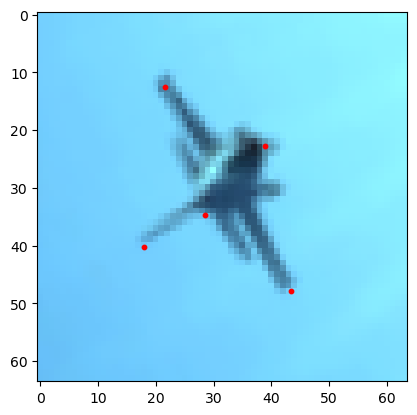

In [16]:
IMG_IDX = 625
IMG = dataset[IMG_IDX]
plt.imshow(torch.permute(IMG['image'], (1, 2, 0)))
# Unpack points into two lists: xs, ys
xs = [p[0] for p in IMG['points']]
ys = [p[1] for p in IMG['points']]
# Plot points as red circles
plt.scatter(xs, ys, c='red', s=10)  # s = point size

tensor(0.) tensor(4.4878)
torch.Size([5, 64, 64])


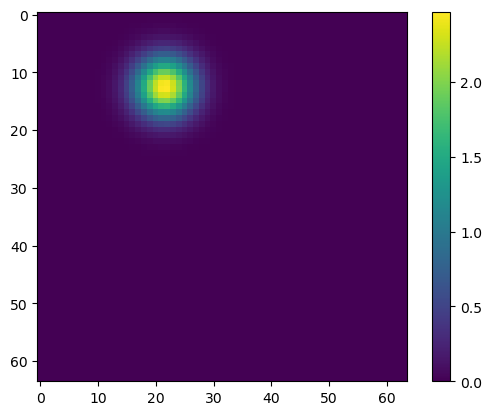

In [17]:
print(torch.min(IMG['heatmaps']), torch.max(IMG['heatmaps']))
print(IMG['heatmaps'].shape)
plt.imshow(IMG['heatmaps'][1])
plt.colorbar()

In [18]:
print(IMG['points'])

tensor([[38.9219, 22.8282],
        [21.5995, 12.6174],
        [43.3667, 47.8779],
        [28.4736, 34.6505],
        [17.8885, 40.1831]])


tensor(0.) tensor(4.4878)


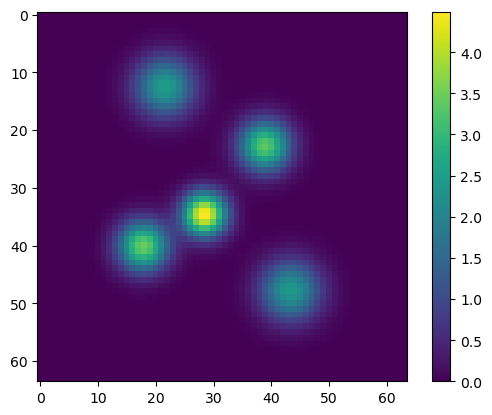

In [19]:
print(torch.min(IMG['heatmaps']), torch.max(IMG['heatmaps']))
plt.imshow(torch.sum(IMG['heatmaps'], axis=0))
plt.colorbar()

In [20]:
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

for batch in loader:
    print(batch["frame"])
    print(batch["points"].shape)  # (B, N, 2)
    break

tensor([   0,    1,   29,   50,   63,   79,  103,  139,  181,  216,  248,  273,
         296,  325,  347,  366,  378,  420,  441,  480,  521,  557,  620,  743,
         831,  857,  879,  929, 1015, 1056, 1065, 1077, 1080, 1082, 1084, 1086,
        1088, 1090, 1095, 1102, 1105, 1111, 1122, 1130, 1141, 1155, 1165, 1187,
        1198, 1218, 1227, 1240, 1248, 1255, 1269, 1287, 1302, 1324, 1350, 1360,
        1372, 1392, 1402, 1431, 1444, 1446, 1450, 1453, 1457, 1463, 1466, 1469,
        1473, 1479, 1485, 1489, 1496, 1499, 1503, 1511, 1520, 1540, 1549, 1566,
        1572, 1579, 1601, 1621, 1641, 1653, 1663, 1676, 1686, 1709, 1784, 1862,
        1884, 1908, 1929, 1962, 2045, 2074, 2087, 2094, 2104, 2115, 2120, 2126,
        2135, 2148, 2169, 2205, 2224, 2245, 2327, 2375, 2422, 2468])
torch.Size([118, 5, 2])


In [21]:
trial_number = 0

from datetime import datetime
import time

# instantiate generator, discriminator
# borrowed from https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")
print("device: ", device)

print("Instantiating StackedHourglass")
model = StackedHourglass(3, NUM_LANDMARKS).to(device, dtype=torch.float32)
print(model)

# Setup Adam optimizers for both G and D
optimizer = optim.Adam(model.parameters(), lr=0.0005, betas=(0.5, 0.999))
print("Model optimizer: \n", optimizer)

criterions = [nn.MSELoss() for _ in range(5)]

device:  cpu
Instantiating StackedHourglass
StackedHourglass(
  (unet1): UNet(
    (init_conv): SameSizeConv(
      (conv_layers): Sequential(
        (0): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
        (3): Dropout(p=0, inplace=False)
        (4): Conv2d(3, 3, kernel_size=(5, 5), stride=(1, 1), padding=(4, 4), dilation=(2, 2), bias=False)
        (5): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): LeakyReLU(negative_slope=0.01)
        (7): Dropout(p=0, inplace=False)
        (8): Conv2d(3, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (9): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (10): LeakyReLU(negative_slope=0.01)
        (11): Dropout(p=0, inplace=False)
        (12): Conv2d(3, 3, kernel_size=(

In [22]:
iters = 0
epoch = 0
num_epochs = 1000
#k=500 # saving images of fixed_noise outputs
last_save = iters
break_flag = False

losses = []

example_idx = 110

In [29]:
xs = torch.linspace(0.5, model_image_size-0.5, model_image_size, device=device) / model_image_size
ys = torch.linspace(0.5, model_image_size-0.5, model_image_size, device=device) / model_image_size
X, Y = torch.meshgrid(xs, ys, indexing="xy")
pts_template = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=-1)  # (N, 2), N = grid_size^2

print("Starting Training Loop...")
while (epoch < num_epochs) and (not break_flag):
    # For each batch in the dataloader
    should_break = False
    err_total_loss = 0
    
    for i, data in enumerate(loader, 0):
        print("Epoch\t"+str(epoch)+", batch\t"+str(i)+".", end="\n")

        data_input = data['image']
        output = data['heatmaps']
        output_coords = data['points'] / model_image_size

        data_input = data_input.to(device, dtype=torch.float32)

        b = data_input.shape[0]
        c = output.shape[1]
        heatmap_predicted = model(data_input)

        model.zero_grad()

        errs = []
        for j in range(len(heatmap_predicted)):
            errs.append(criterions[j](heatmap_predicted[j], output))
            if j == 0:
                print(f"Error for final: {errs[0].item()}")
            else:
                print(f"Error for intermediate heatmap {j}: {errs[j].item()}")
        losses.append((epoch, i, iters, {f"Stage {j} error": errs[j].item() for j in range(len(heatmap_predicted))} ) )

        err_sum = (sum(errs)/len(errs)) * b / batch_size
        print(f"Average error: {err_sum.item()}")
        err_total_loss += err_sum.item()
        err_sum.backward()

        optimizer.step()

        iters += 1

    print(f"Total error: {err_total_loss}")
    losses.append((epoch, -1, iters, {f"Total error": err_total_loss} ) )
    
    
    
    if should_break:
        break

    if (epoch+1) % 5 == 0:
        print(f"Saving results for example index {example_idx}")
        # output example output from model
        example_point = dataset[example_idx]
        image = torch.permute(example_point['image'], (1, 2, 0))
        plt.imshow(image.numpy())
        plt.savefig(f"{output_dir}/epoch{epoch}_in.png")
        plt.clf()

        input_example = example_point['image'].to(dtype=torch.float32)
        print(torch.min(input_example), torch.max(input_example))
        print(input_example.shape)

        model.eval()
        heatmap_pred = model( torch.stack((input_example,)) )
        heatmap_pred_detach = [x.detach() for x in heatmap_pred]
        model.train()

        heatmap_actual = example_point['heatmaps']
        print(heatmap_pred[0].shape)
        for i in range(NUM_LANDMARKS):
            plt.imshow(heatmap_actual.numpy()[i])
            plt.colorbar()
            plt.savefig(f"{output_dir}/epoch{epoch}_out_{i}_real.png")
            plt.clf()
            for j in range(len(heatmap_pred_detach)):
                plt.imshow(heatmap_pred_detach[j].numpy()[0][i])
                plt.colorbar()
                plt.savefig(f"{output_dir}/epoch{epoch}_out_{i}_{j}.png")
                plt.clf()

    epoch += 1
    #SIGMA_RATIO = ((SIGMA_RATIO - 0.05) * 0.996) + 0.05
    print(f"New SIGMA_RATIO: {SIGMA_RATIO}")

Starting Training Loop...
Epoch	473, batch	0.
Error for final: 0.04780223220586777
Error for intermediate heatmap 1: 0.08600571751594543
Error for intermediate heatmap 2: 0.08149846643209457
Error for intermediate heatmap 3: 0.07997948676347733
Error for intermediate heatmap 4: 0.0767727866768837
Average error: 0.07441173493862152
Epoch	473, batch	1.
Error for final: 0.11690739542245865
Error for intermediate heatmap 1: 0.09689487516880035
Error for intermediate heatmap 2: 0.09533075988292694
Error for intermediate heatmap 3: 0.09410616010427475
Error for intermediate heatmap 4: 0.09730977565050125
Average error: 0.10010980069637299
Epoch	473, batch	2.
Error for final: 0.10332340002059937
Error for intermediate heatmap 1: 0.10023728758096695
Error for intermediate heatmap 2: 0.10191484540700912
Error for intermediate heatmap 3: 0.09466855227947235
Error for intermediate heatmap 4: 0.09885229915380478
Average error: 0.09979928284883499
Epoch	473, batch	3.
Error for final: 0.098418407142

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [28]:
# new_beta2 = 0.99
# for param_group in optimizer.param_groups:
#     # param_group['betas'] is a tuple, so we create a new tuple
#     param_group['betas'] = (param_group['betas'][0], new_beta2)
new_lr = 0.0075
for param_group in optimizer.param_groups:
    param_group['lr'] = new_lr

Text(0, 0.5, 'Log loss')

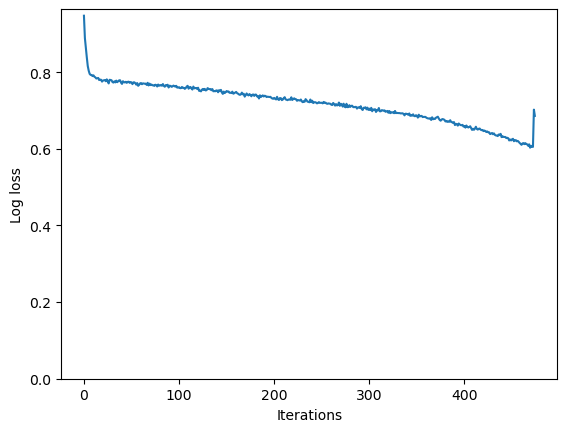

In [30]:
import math
plt.plot([x[0] for x in losses if x[1]==-1], [x[3]["Total error"] for x in losses if x[1]==-1])
plt.ylim(bottom=0)
plt.xlabel("Iterations")
plt.ylabel("Log loss")

Text(0, 0.5, 'Log loss (Stage 0)')

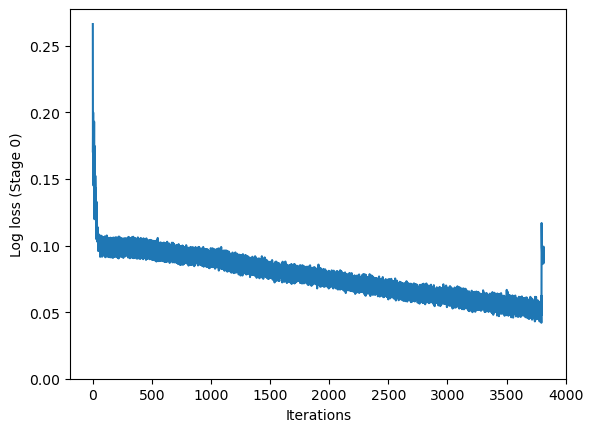

In [44]:
import math
plt.plot([x[2] for x in losses if x[1]!=-1], [x[3]["Stage 0 error"] for x in losses if x[1]!=-1])
plt.ylim(bottom=0)
plt.xlabel("Iterations")
plt.ylabel("Log loss (Stage 0)")